In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cv2
import glob


## (a) Desain Kernel

Kernel yang dipilih adalah **Laplacian 4-tetangga**:

```
K = [[ 0, -1,  0],
     [-1,  4, -1],
     [ 0, -1,  0]]
```

- Nilai pusat `+4`: mengangkat intensitas piksel pusat terhadap sekitarnya  
- Nilai tetangga `-1`: mengurangi kontribusi piksel atas/bawah/kiri/kanan  
- Hasil ≈ **0** pada area seragam (daun sehat), **tinggi** pada area bertekstur/berbercak (sakit)  
- Diagonal = 0 agar fokus pada struktur aksial, tidak terlalu sensitif terhadap noise diagonal


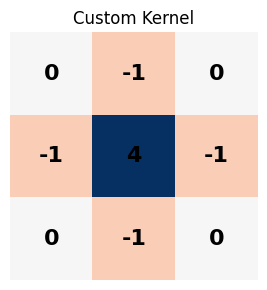

In [14]:
kernel = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=float)

# Visualisasi kernel
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(kernel, cmap='RdBu', vmin=-4, vmax=4)
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(kernel[i, j]),
                ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_title("Custom Kernel", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


## (b) Terapkan Kernel pada 5 Sampel per Kelas


In [15]:
CLASSES = {
    "Apple Scab":       "./data/apple-scab/",
    "Apple Rust":       "./data/apple-rust/",
    "Apple Black Rot":  "./data/apple-blackrot/",
}
N = 5

def load_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    return img.astype(float) / 255.0

class_means = {}   # {kelas: [mean_abs per gambar]}
sample_data  = {}  # {kelas: (img, res)} untuk visualisasi

for cls_name, folder in CLASSES.items():
    files = sorted(glob.glob(folder + "*.JPG"))[:N]
    means = []
    for i, fpath in enumerate(files):
        img = load_gray(fpath)
        res = signal.convolve2d(img, kernel, mode='same', boundary='symm')
        means.append(np.mean(np.abs(res)))
        if i == 0:
            sample_data[cls_name] = (img, res)
    class_means[cls_name] = means
    print(f"{cls_name}: {[f'{v:.4f}' for v in means]}  →  rata-rata = {np.mean(means):.4f}")


Apple Scab: ['0.0305', '0.0330', '0.1256', '0.2221', '0.2162']  →  rata-rata = 0.1255
Apple Rust: ['0.0415', '0.0466', '0.0487', '0.0512', '0.0418']  →  rata-rata = 0.0460
Apple Black Rot: ['0.2359', '0.2626', '0.1457', '0.1570', '0.1450']  →  rata-rata = 0.1892


### Visualisasi Sampel Pertama per Kelas

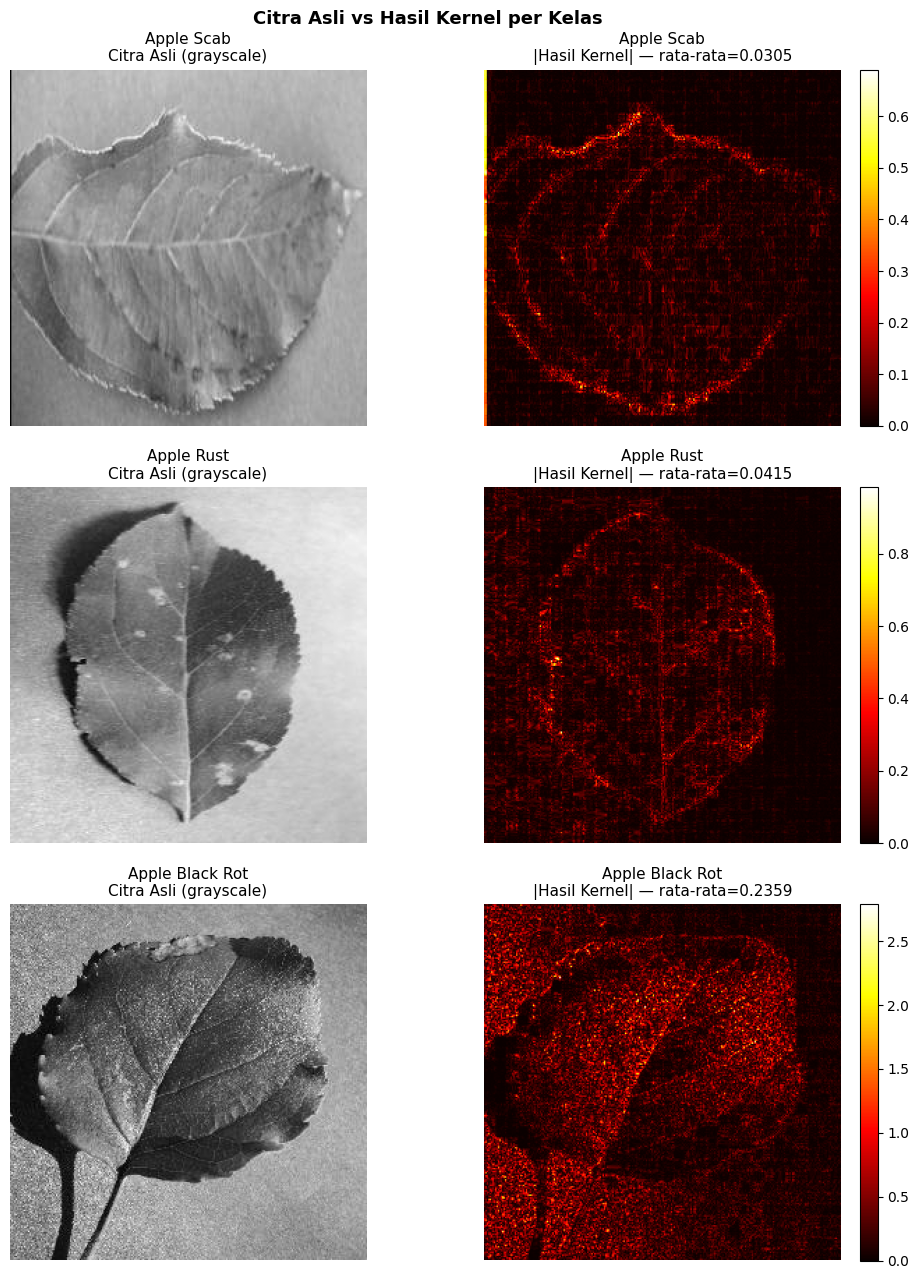

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(10, 13))
fig.suptitle("Citra Asli vs Hasil Kernel per Kelas", fontsize=13, fontweight='bold')

for ax_row, (cls_name, (img, res)) in zip(axes, sample_data.items()):
    ax_row[0].imshow(img, cmap='gray')
    ax_row[0].set_title(f"{cls_name}\nCitra Asli (grayscale)", fontsize=11)
    ax_row[0].axis('off')

    im = ax_row[1].imshow(np.abs(res), cmap='hot')
    ax_row[1].set_title(f"{cls_name}\n|Hasil Kernel| — rata-rata={np.mean(np.abs(res)):.4f}", fontsize=11)
    ax_row[1].axis('off')
    plt.colorbar(im, ax=ax_row[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("result_texture_samples.png", dpi=200, bbox_inches='tight')
plt.show()


### Bar Chart Rata-Rata per Kelas

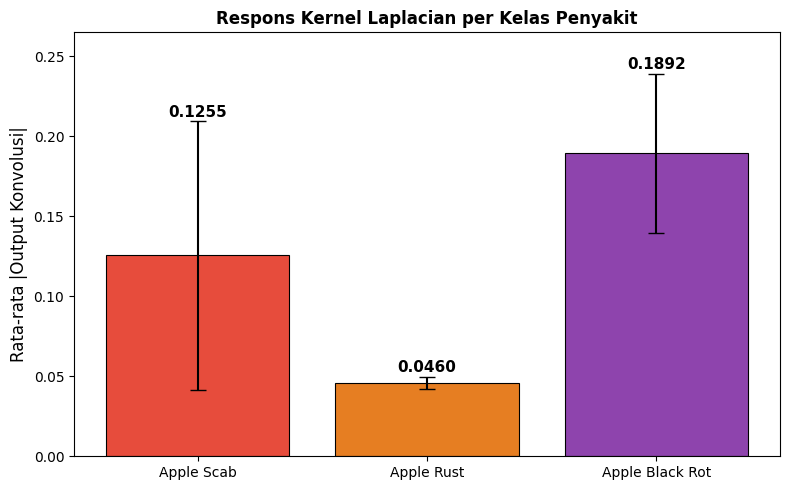

In [17]:
cls_names = list(class_means.keys())
means = [np.mean(v) for v in class_means.values()]
stds  = [np.std(v)  for v in class_means.values()]
colors = ['#e74c3c', '#e67e22', '#8e44ad']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cls_names, means, yerr=stds, capsize=6,
              color=colors, edgecolor='black', linewidth=0.8)
ax.set_ylabel("Rata-rata |Output Konvolusi|", fontsize=12)
ax.set_title("Respons Kernel Laplacian per Kelas Penyakit", fontsize=12, fontweight='bold')
ax.set_ylim(0, max(means) * 1.4)

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("result_texture_barchart.png", dpi=200, bbox_inches='tight')
plt.show()


## (c) Evaluasi Kernel

Amati bar chart di atas:
- Jika **selisih rata-rata antar kelas ≥ 0.02** → kernel cukup memisahkan ketiga kelas ✅  
- Jika belum terpisah, jalankan cell di bawah untuk mencoba **kernel v2 (Laplacian 8-tetangga)**


In [18]:
# Kernel v2 — Laplacian 8-tetangga (respons lebih kuat, lebih sensitif diagonal)
kernel_v2 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=float)

print("Hasil kernel v2 (Laplacian 8-tetangga):")
for cls_name, folder in CLASSES.items():
    files = sorted(glob.glob(folder + "*.JPG"))[:N]
    means = []
    for fpath in files:
        img = load_gray(fpath)
        res = signal.convolve2d(img, kernel_v2, mode='same', boundary='symm')
        means.append(np.mean(np.abs(res)))
    print(f"  {cls_name:20s}: rata-rata = {np.mean(means):.4f}")


Hasil kernel v2 (Laplacian 8-tetangga):
  Apple Scab          : rata-rata = 0.2620
  Apple Rust          : rata-rata = 0.1165
  Apple Black Rot     : rata-rata = 0.3873


## (d) Diskusi: Fixed Kernel vs. Learned Kernels (CNN)

**Konvolusi dengan kernel tetap** (seperti Laplacian yang digunakan di atas):
- Interpretabilitas tinggi — makna fisik tiap nilai kernel jelas
- Tidak butuh data latih, langsung bisa diterapkan
- Keterbatasan: satu kernel hanya menangkap satu jenis fitur; pola penyakit kompleks (multiskala, multi-warna) sulit dibedakan hanya dari rata-rata satu konvolusi

**Learned kernels pada CNN**:
- Layer pertama CNN mempelajari filter yang secara fungsional menyerupai Sobel/Gaussian/Laplacian, namun dioptimalkan khusus untuk tugas klasifikasi yang diberikan
- Layer lebih dalam menggabungkan fitur tingkat rendah menjadi representasi tingkat tinggi (bentuk lesi, pola bercak, distribusi warna)
- Untuk dataset sebesar New Plant Disease (87.000 gambar, 38 kelas), CNN jauh lebih unggul

**Kesimpulan**: Kernel manual berguna sebagai langkah eksplorasi awal dan preprocessing (noise reduction, edge enhancement), sedangkan CNN cocok untuk sistem produksi yang membutuhkan akurasi tinggi pada banyak kelas.
